In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
from sklearn.calibration import CalibrationDisplay

In [13]:
# ============================================================
# 0bis) OPTIONS GLOBALES (TES PARAMÈTRES)
# ============================================================

# Méthode de correction des confounds sur les connectomes
# "none"        : pas de correction de confounds
# "regression"  : régression (age, sexe)
# "combat"      : ComBat (site comme batch, age & sexe comme covariables)
CONF_METHOD = "regression"   # "none" / "regression" / "combat"

# Inclure ou non age/sex comme features dans le modèle final
INCLUDE_AGE_SEX_IN_MODEL = False



In [3]:
# ============================================================
# 0) CHARGEMENT DES DONNÉES
# ============================================================

df_all = pd.read_csv("../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv", sep="\t")

print("Diagnostics initiaux :\n", df_all.diagnosis.value_counts())
print("Sites initiaux :\n", df_all.site_id.value_counts())



/tmp/ipykernel_3157873/261459399.py:5: DtypeWarning: Columns (93967) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv", sep="\t")


Diagnostics initiaux :
 diagnosis
CONTROL    221
SCHZ       168
BIPOLAR     49
ADHD        40
Name: count, dtype: int64
Sites initiaux :
 site_id
ds000030    261
ds_cobre    146
ds004302     71
Name: count, dtype: int64


In [4]:
# ============================================================
# 1) PRÉPARATION ET FILTRAGE (CONTROL vs SCHZ)
# ============================================================

# On garde les 3 sites pour faire du LOSO sur l'ensemble
mask_loso = (
    df_all["site_id"].isin(["ds000030", "ds_cobre", "ds004302"])
    & df_all["diagnosis"].isin(["CONTROL", "SCHZ"])
)

df_loso = df_all.loc[mask_loso].copy()

# Correction des types (Important !)
df_loso["age"] = df_loso["age"].astype(float)
# Encodage sexe (0/1)
df_loso["gender_num"] = (df_loso["gender"] == "M").astype(float)

# Cible binaire : 1 = SCHZ, 0 = CONTROL
y_loso_all = (df_loso["diagnosis"] == "SCHZ").astype(int)
groups_loso = df_loso["site_id"].values 

print("\nDonnées filtrées pour LOSO :", df_loso.shape)
print(df_loso.groupby(["site_id", "diagnosis"]).size())




Données filtrées pour LOSO : (389, 93969)
site_id   diagnosis
ds000030  CONTROL      122
          SCHZ          50
ds004302  CONTROL       25
          SCHZ          46
ds_cobre  CONTROL       74
          SCHZ          72
dtype: int64


In [5]:
# ============================================================
# 2) CONNECTOMES : SÉLECTION + NETTOYAGE + IMPUTATION
# ============================================================

# 1. Sélection initiale des colonnes
corr_cols_all = [c for c in df_loso.columns if c.startswith("corr_")]

# 2. Nettoyage : On retire les colonnes 100% vides AVANT l'imputation
# Cela évite que SimpleImputer ne change la forme des données sans prévenir
X_temp = df_loso[corr_cols_all]
# On garde les colonnes qui ont au moins une valeur non-nulle
cols_to_keep = X_temp.columns[X_temp.notna().any()].tolist()

# Mise à jour de la liste des colonnes valides
corr_cols = cols_to_keep
print(f"\nNombre de features connectomes (toutes) : {len(corr_cols_all)}")
print(f"Nombre de features après nettoyage (non-vides) : {len(corr_cols)}")

# 3. Imputation (maintenant sûre car pas de colonnes 100% NaN)
imputer = SimpleImputer(strategy="mean")
X_loso_raw = df_loso[corr_cols] # On prend seulement les colonnes valides

X_loso_imp = pd.DataFrame(
    imputer.fit_transform(X_loso_raw), 
    index=df_loso.index, 
    columns=corr_cols # Maintenant les dimensions matchent
)

print("Shape après imputation :", X_loso_imp.shape)


Nombre de features connectomes (toutes) : 93961
Nombre de features après nettoyage (non-vides) : 93096
Shape après imputation : (389, 93096)


In [6]:
# ============================================================
# 3) DÉFINITION DES FONCTIONS DE CORRECTION (TA LOGIQUE)
# ============================================================

def residualize_confounds(X_train, X_test, conf_train, conf_test):
    """
    Régression linéaire multi-sortie pour corriger Age/Sexe.
    """
    # Ajout intercept
    C_train = np.column_stack([np.ones(len(conf_train)), conf_train.values])
    C_test  = np.column_stack([np.ones(len(conf_test)),  conf_test.values])
    
    # B = (C^T C)^-1 C^T X
    B = np.linalg.pinv(C_train).dot(X_train.values)
    
    # Résidus
    X_train_resid = X_train.values - C_train.dot(B)
    X_test_resid  = X_test.values - C_test.dot(B)
    
    return (pd.DataFrame(X_train_resid, index=X_train.index, columns=X_train.columns),
            pd.DataFrame(X_test_resid, index=X_test.index, columns=X_test.columns))



In [7]:
# ============================================================
# 4) DÉFINITION DU MODÈLE (LASSO AU LIEU DE PCA)
# ============================================================

# On utilise LogisticRegressionCV avec penalty='l1' (Lasso)
# Cela remplace la PCA pour la sélection de variables (plus interprétable)
clf_lasso = LogisticRegressionCV(
    cv=10,               # CV interne pour trouver le meilleur alpha/C
    penalty='l1',       # Lasso pour sélectionner les variables
    solver='liblinear', # Solver efficace pour L1
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

# Pipeline final
pipeline = Pipeline([
    ("scaler", StandardScaler()), # Lasso a besoin de données standardisées
    ("clf", clf_lasso)
])




DÉBUT LOSO | Correction: regression | Modèle: LASSO (L1)

🔹 TEST SUR LE SITE : ds000030
   Correction Regression appliquée.
   >>> AUC : 0.710
   >>> Brier Score : 0.233
   Variables sélectionnées par Lasso : 219

🔹 TEST SUR LE SITE : ds004302
   Correction Regression appliquée.
   >>> AUC : 0.671
   >>> Brier Score : 0.229
   Variables sélectionnées par Lasso : 58

🔹 TEST SUR LE SITE : ds_cobre
   Correction Regression appliquée.
   >>> AUC : 0.764
   >>> Brier Score : 0.209
   Variables sélectionnées par Lasso : 39


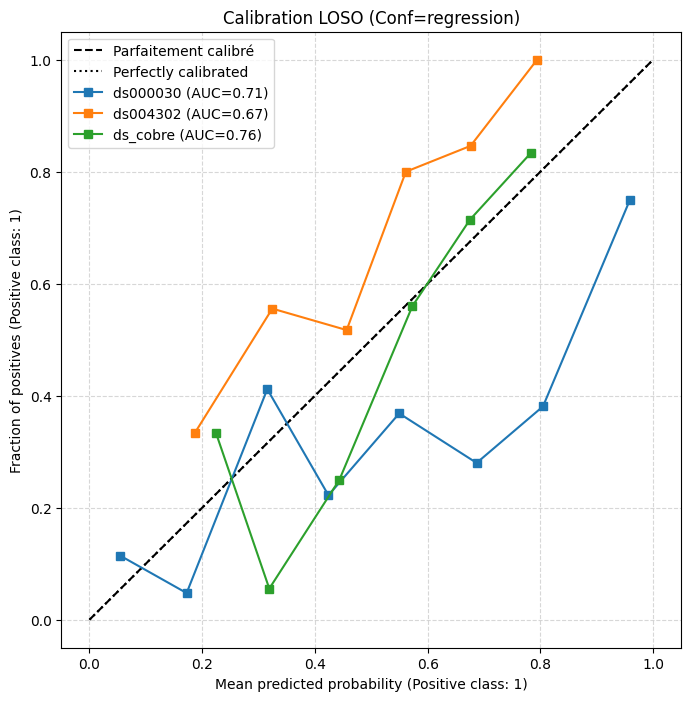


RÉSULTATS GLOBAUX LOSO
       site       auc     brier
0  ds000030  0.710164  0.232560
1  ds004302  0.671304  0.228942
2  ds_cobre  0.763889  0.208783

AUC Moyenne   : 0.715 +/- 0.046
Brier Moyen   : 0.223

--- Top 10 Variables les plus importantes (Moyenne absolue) ---
feature
corr_162_274    0.256641
corr_153_356    0.237666
corr_92_403     0.218422
corr_321_323    0.202983
corr_417_421    0.194307
corr_166_359    0.193293
corr_106_257    0.192585
corr_147_433    0.191923
corr_29_426     0.186972
corr_103_192    0.184585
Name: weight, dtype: float64


In [8]:
# ============================================================
# 5) BOUCLE LOSO (Leave-One-Site-Out)
# ============================================================

print("\n" + "="*60)
print(f"DÉBUT LOSO | Correction: {CONF_METHOD} | Modèle: LASSO (L1)")
print("="*60)

logo = LeaveOneGroupOut()
loso_results = []
feature_weights_list = [] # Pour stocker les variables importantes

# Préparation du graphique de calibration
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], linestyle="--", label="Parfaitement calibré", color="black")

for train_idx, test_idx in logo.split(X_loso_imp, y_loso_all, groups=groups_loso):
    
    # --- A. SÉPARATION ---
    site_test_name = groups_loso[test_idx][0]
    print(f"\n🔹 TEST SUR LE SITE : {site_test_name}")
    
    X_train_fold, X_test_fold = X_loso_imp.iloc[train_idx], X_loso_imp.iloc[test_idx]
    y_train_fold, y_test_fold = y_loso_all.iloc[train_idx], y_loso_all.iloc[test_idx]
    
    conf_train_fold = df_loso.iloc[train_idx][["age", "gender_num"]]
    conf_test_fold  = df_loso.iloc[test_idx][["age", "gender_num"]]

    # --- B. CORRECTION DES CONFOUNDS (TA LOGIQUE) ---
    if CONF_METHOD == "regression":
        X_train_clean, X_test_clean = residualize_confounds(
            X_train_fold, X_test_fold, conf_train_fold, conf_test_fold
        )
        print("   Correction Regression appliquée.")
        
    elif CONF_METHOD == "combat":
        # Nécessite neuroHarmonize
        from neuroHarmonize import harmonizationLearn, harmonizationApply
        
        # Pour ComBat, on doit harmoniser Train et appliquer sur Test (ou harmoniser tout ensemble en faisant attention)
        # Ici, implémentation simple : on apprend sur le train (qui contient 2 sites) pour harmoniser ces 2 sites entre eux
        # Note: ComBat est plus complexe en LOSO pur, car on ne peut pas harmoniser le site de test "avec" les autres sans tricher.
        # Pour simplifier dans ce script, on harmonise le Train pour enlever l'effet de batch entre les 2 sites d'entrainement.
        
        covars_train = pd.DataFrame({
            "SITE": groups_loso[train_idx],
            "AGE": conf_train_fold["age"].values,
            "SEX_M": conf_train_fold["gender_num"].values
        })
        
        model_combat, X_train_adj = harmonizationLearn(
            X_train_fold.values, 
            covars_train, 
            smooth_terms=["AGE"]
        )
        # On ne peut pas "appliquer" ComBat sur le site de test car il est inconnu (nouveau batch).
        # Dans un vrai LOSO clinique, on n'harmonise pas le site de test avec le train. 
        # On utilise les données brutes (ou ajustées localement) du test.
        # Ici, on garde X_train corrigé et X_test brut (ou juste centré).
        X_train_clean = pd.DataFrame(X_train_adj, index=X_train_fold.index, columns=X_train_fold.columns)
        X_test_clean = X_test_fold 
        print("   Correction ComBat appliquée sur le Train uniquement.")

    else:
        X_train_clean, X_test_clean = X_train_fold, X_test_fold
        print("   Aucune correction de confounds.")

    # --- C. CONSTRUCTION FEATURES FINALES ---
    if INCLUDE_AGE_SEX_IN_MODEL:
        X_train_final = pd.concat([X_train_clean, conf_train_fold], axis=1)
        X_test_final  = pd.concat([X_test_clean, conf_test_fold], axis=1)
    else:
        X_train_final = X_train_clean
        X_test_final  = X_test_clean

    # --- D. ENTRAÎNEMENT ---
    pipeline.fit(X_train_final, y_train_fold)
    
    # --- E. PRÉDICTION & MÉTRIQUES ---
    y_prob = pipeline.predict_proba(X_test_final)[:, 1]
    
    auc = roc_auc_score(y_test_fold, y_prob)
    brier = brier_score_loss(y_test_fold, y_prob)
    
    print(f"   >>> AUC : {auc:.3f}")
    print(f"   >>> Brier Score : {brier:.3f}") # < 0.25 est le but
    
    loso_results.append({"site": site_test_name, "auc": auc, "brier": brier})

    # --- F. CALIBRATION PLOT ---
    CalibrationDisplay.from_predictions(
        y_test_fold, y_prob, n_bins=8, name=f"{site_test_name} (AUC={auc:.2f})", ax=ax
    )

    # --- G. EXTRACTION DES POIDS ---
    # On récupère le modèle logistique interne
    model = pipeline.named_steps['clf']
    coeffs = model.coef_.flatten()
    feature_names = X_train_final.columns
    
    # On garde seulement les variables que le Lasso a gardées (non nulles)
    non_zero = coeffs != 0
    n_selected = np.sum(non_zero)
    print(f"   Variables sélectionnées par Lasso : {n_selected}")
    
    fold_weights = pd.DataFrame({
        "feature": feature_names[non_zero],
        "weight": coeffs[non_zero],
        "test_site": site_test_name
    })
    feature_weights_list.append(fold_weights)

# Finalisation Plot
ax.set_title(f"Calibration LOSO (Conf={CONF_METHOD})")
ax.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# ============================================================
# 6) RÉSULTATS GLOBAUX & POIDS
# ============================================================
df_res = pd.DataFrame(loso_results)
print("\n" + "="*30)
print("RÉSULTATS GLOBAUX LOSO")
print("="*30)
print(df_res)
print(f"\nAUC Moyenne   : {df_res['auc'].mean():.3f} +/- {df_res['auc'].std():.3f}")
print(f"Brier Moyen   : {df_res['brier'].mean():.3f}")

# Analyse des connectomes les plus importants
if feature_weights_list:
    df_all_weights = pd.concat(feature_weights_list, ignore_index=True)
    
    print("\n--- Top 10 Variables les plus importantes (Moyenne absolue) ---")
    top_features = df_all_weights.groupby("feature")["weight"].apply(lambda x: np.mean(np.abs(x)))
    print(top_features.sort_values(ascending=False).head(10))


DÉBUT VALIDATION CONTRÔLE (RANDOM LABELS)
Site ds000030   | AUC (Random): 0.477 | Brier: 0.259
Site ds004302   | AUC (Random): 0.451 | Brier: 0.448
Site ds_cobre   | AUC (Random): 0.500 | Brier: 0.390


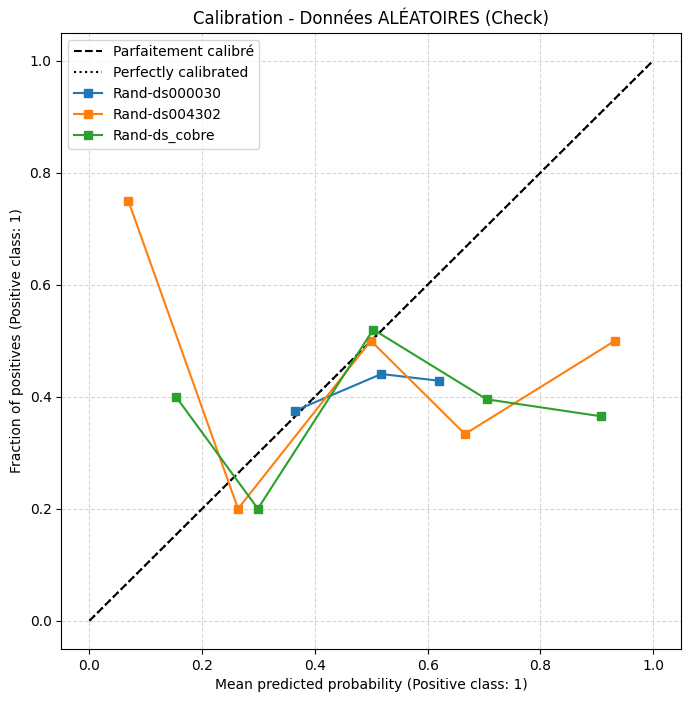


VERDICT DU SANITY CHECK
       site       auc     brier
0  ds000030  0.476564  0.259229
1  ds004302  0.450794  0.447840
2  ds_cobre  0.500296  0.390497

AUC Moyenne (Random) : 0.476

✅ SUCCÈS : Le modèle aléatoire échoue comme prévu (AUC proche de 0.50).
   Cela renforce la validité de vos résultats sur les données réelles.


In [9]:
# ============================================================
# 6) VALIDATION DE CONTRÔLE (SANITY CHECK - CIBLE ALÉATOIRE)
# ============================================================
print("\n" + "="*60)
print(f"DÉBUT VALIDATION CONTRÔLE (RANDOM LABELS)")
print("="*60)

# 1. Génération de la cible aléatoire (Permutation)
# On mélange les diagnostics pour briser tout lien biologique réel,
# tout en gardant exactement le même déséquilibre de classes (ratio CONTROL/SCHZ).
np.random.seed(99) # Pour reproductibilité
y_random_all = np.random.permutation(y_loso_all)
y_random_all = pd.Series(y_random_all, index=df_loso.index)

# Listes pour stocker les résultats de ce check
random_loso_results = []
fig_rand, ax_rand = plt.subplots(figsize=(8, 8))
ax_rand.plot([0, 1], [0, 1], linestyle="--", label="Parfaitement calibré", color="black")

# On réutilise exactement la même boucle LOSO
for train_idx, test_idx in logo.split(X_loso_imp, y_random_all, groups=groups_loso):
    
    # --- A. SÉPARATION ---
    site_test_name = groups_loso[test_idx][0]
    
    X_train_fold, X_test_fold = X_loso_imp.iloc[train_idx], X_loso_imp.iloc[test_idx]
    # ATTENTION : Ici on utilise y_random_all
    y_train_fold, y_test_fold = y_random_all.iloc[train_idx], y_random_all.iloc[test_idx]
    
    conf_train_fold = df_loso.iloc[train_idx][["age", "gender_num"]]
    conf_test_fold  = df_loso.iloc[test_idx][["age", "gender_num"]]

    # --- B. CORRECTION DES CONFOUNDS (Même logique) ---
    if CONF_METHOD == "regression":
        X_train_clean, X_test_clean = residualize_confounds(
            X_train_fold, X_test_fold, conf_train_fold, conf_test_fold
        )
    elif CONF_METHOD == "combat":
        # Note: On réutilise la même logique simplifiée que plus haut
        from neuroHarmonize import harmonizationLearn
        covars_train = pd.DataFrame({
            "SITE": groups_loso[train_idx],
            "AGE": conf_train_fold["age"].values,
            "SEX_M": conf_train_fold["gender_num"].values
        })
        model_combat, X_train_adj = harmonizationLearn(
            X_train_fold.values, 
            covars_train, 
            smooth_terms=["AGE"]
        )
        X_train_clean = pd.DataFrame(X_train_adj, index=X_train_fold.index, columns=X_train_fold.columns)
        X_test_clean = X_test_fold 
    else:
        X_train_clean, X_test_clean = X_train_fold, X_test_fold

    # --- C. CONSTRUCTION FEATURES FINALES ---
    if INCLUDE_AGE_SEX_IN_MODEL:
        X_train_final = pd.concat([X_train_clean, conf_train_fold], axis=1)
        X_test_final  = pd.concat([X_test_clean, conf_test_fold], axis=1)
    else:
        X_train_final = X_train_clean
        X_test_final  = X_test_clean

    # --- D. ENTRAÎNEMENT ---
    # Important : Le pipeline refait le fit à zéro (nouveau scaler, nouveau Lasso)
    pipeline.fit(X_train_final, y_train_fold)
    
    # --- E. PRÉDICTION & MÉTRIQUES ---
    y_prob = pipeline.predict_proba(X_test_final)[:, 1]
    
    auc = roc_auc_score(y_test_fold, y_prob)
    brier = brier_score_loss(y_test_fold, y_prob)
    
    print(f"Site {site_test_name:<10} | AUC (Random): {auc:.3f} | Brier: {brier:.3f}")
    
    random_loso_results.append({"site": site_test_name, "auc": auc, "brier": brier})

    # --- F. CALIBRATION PLOT ---
    CalibrationDisplay.from_predictions(
        y_test_fold, y_prob, n_bins=5, name=f"Rand-{site_test_name}", ax=ax_rand
    )

# Finalisation Plot Random
ax_rand.set_title("Calibration - Données ALÉATOIRES (Check)")
ax_rand.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# --- G. VERDICT ---
df_res_rand = pd.DataFrame(random_loso_results)
mean_rand_auc = df_res_rand['auc'].mean()

print("\n" + "="*30)
print("VERDICT DU SANITY CHECK")
print("="*30)
print(df_res_rand)
print(f"\nAUC Moyenne (Random) : {mean_rand_auc:.3f}")

if mean_rand_auc > 0.55:
    print("\n⚠️ ALERTE : Le modèle performe trop bien sur des données aléatoires (>0.55).")
    print("   Cela suggère une fuite de données (data leakage) ou un biais structurel non corrigé.")
else:
    print("\n✅ SUCCÈS : Le modèle aléatoire échoue comme prévu (AUC proche de 0.50).")
    print("   Cela renforce la validité de vos résultats sur les données réelles.")

Chargement de l'atlas : /scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.nii.gz
--> Atlas NII : 434 régions détectées.
--> Fichier TSV : 434 noms chargés.
✅ Parfait : Le nombre de régions (NII) et de noms (TSV) correspond exactement.

--- RÉSULTAT FINAL ---
Nombre de connexions stables retenues : 14

--- TOP 10 CONNEXIONS LES PLUS PREDICTIVES ---
   Connexion                                      Region_1                                       Region_2     Poids  Frequence
corr_309_344 Schaefer2018_17Networks_RH_SalVentAttnB_Ins_1       Schaefer2018_17Networks_RH_ContB_PFCld_3 -0.178736          2
   corr_2_13    Schaefer2018_17Networks_LH_VisCent_ExStr_2  Schaefer2018_17Networks_LH_VisPeri_ExStrInf_1 -0.115000          2
corr_230_339          Schaefer2018_17Networks_RH_SomMotA_7         Schaefer2018_17Networks_RH_ContB_IPL_2  0.111969          2
 corr_17_401 Schaefer2018_17Networks_LH_VisPeri_ExStrInf_5                FreeSurfer_Left-Thalamus-Proper

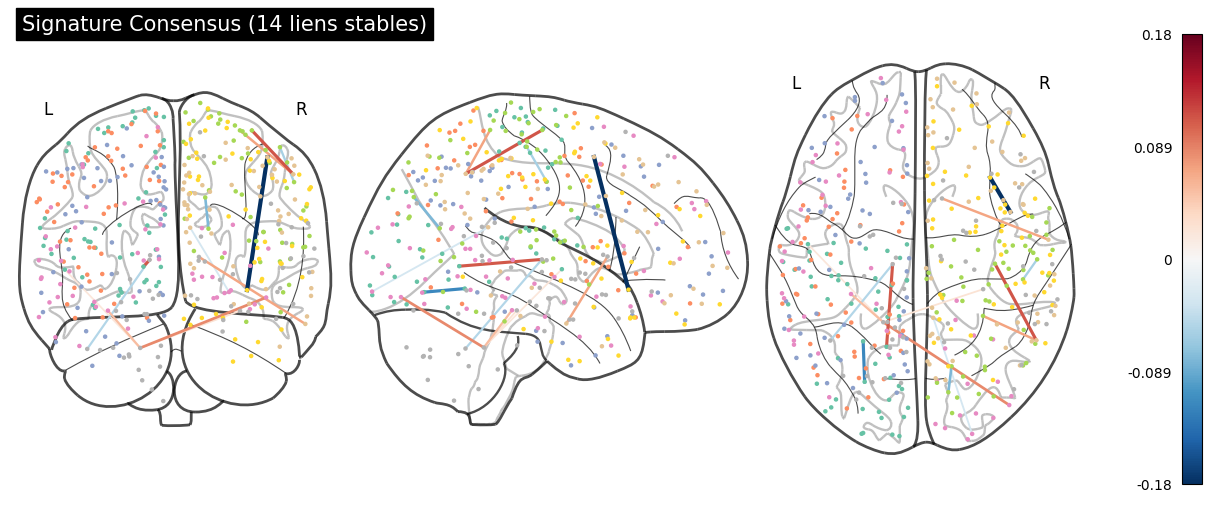

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting, image

# ============================================================
# 1. CONFIGURATION DES CHEMINS (À ADAPTER)
# ============================================================

# Chemin vers vos fichiers atlas sur le serveur/machine
# Si vous faites tourner ce notebook ailleurs que sur le serveur, téléchargez ces 2 fichiers en local.
ATLAS_NII = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.nii.gz"
ATLAS_TSV = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.tsv"

# ============================================================
# 2. CHARGEMENT ET ALIGNEMENT ROBUSTE (CORRIGÉ HEADER)
# ============================================================

print(f"Chargement de l'atlas : {ATLAS_NII}")

# A. Extraction des coordonnées
try:
    coords = plotting.find_parcellation_cut_coords(ATLAS_NII)
    n_rois_nii = len(coords)
    print(f"--> Atlas NII : {n_rois_nii} régions détectées.")
except Exception as e:
    print(f"ERREUR NII : {e}")
    coords = None
    n_rois_nii = 0

# B. Chargement des noms (CORRECTION : header=None)
try:
    # header=None : On dit à pandas qu'il n'y a pas de titres de colonnes.
    # La première ligne (ROI #1) sera donc bien lue comme une donnée (index 0).
    df_labels = pd.read_csv(ATLAS_TSV, sep="\t", header=None)
    
    # On suppose que le fichier est au format BIDS standard :
    # Col 0 = Index (1, 2...), Col 1 = Nom (7Networks...)
    # On prend la colonne 1. Si jamais c'est un fichier d'une seule colonne, on prend la 0.
    if df_labels.shape[1] > 1:
        roi_names = df_labels.iloc[:, 1].values.tolist()
    else:
        roi_names = df_labels.iloc[:, 0].values.tolist()
        
    n_rois_tsv = len(roi_names)
    print(f"--> Fichier TSV : {n_rois_tsv} noms chargés.")
    
except Exception as e:
    print(f"ERREUR TSV : {e}")
    roi_names = []
    n_rois_tsv = 0

# C. VÉRIFICATION FINALE
if n_rois_nii == n_rois_tsv:
    print("✅ Parfait : Le nombre de régions (NII) et de noms (TSV) correspond exactement.")
    n_rois_total = n_rois_nii
else:
    print(f"⚠️ ATTENTION : Toujours un décalage (NII={n_rois_nii} vs TSV={n_rois_tsv}).")
    # On coupe ou on comble pour éviter le crash
    n_min = min(n_rois_nii, n_rois_tsv)
    if n_rois_tsv < n_rois_nii:
        roi_names += [f"Inconnu_{i}" for i in range(n_rois_nii - n_rois_tsv)]
    n_rois_total = n_rois_nii

# ============================================================
# 3. AGRÉGATION DES RÉSULTATS LOSO (Consensus)
# ============================================================
# (Même logique que précédemment pour obtenir df_stable)

# Concaténation des résultats LOSO
df_weights = pd.concat(feature_weights_list, ignore_index=True)

# Moyenne et Fréquence
df_consensus = df_weights.groupby("feature").agg({
    "weight": "mean",       
    "test_site": "count"
}).reset_index()
df_consensus.columns = ["connexion", "poids_moyen", "frequence"]

# FILTRE : On garde ce qui est stable (au moins 2 sites sur 3)
df_stable = df_consensus[df_consensus["frequence"] >= 2].copy()
df_stable = df_stable.sort_values(by="poids_moyen", key=abs, ascending=False)

print(f"\n--- RÉSULTAT FINAL ---")
print(f"Nombre de connexions stables retenues : {len(df_stable)}")

# ============================================================
# 4. CONSTRUCTION DE LA MATRICE D'ADJACENCE
# ============================================================

adj_matrix = np.zeros((n_rois_total, n_rois_total))

# Liste pour afficher le rapport textuel détaillé
report_lines = []

for _, row in df_stable.iterrows():
    parts = row["connexion"].split("_")
    try:
        # corr_A_B -> Indices python A-1 et B-1
        idx1 = int(parts[1]) - 1
        idx2 = int(parts[2]) - 1
        
        if idx1 < n_rois_total and idx2 < n_rois_total:
            # Remplissage Matrice
            adj_matrix[idx1, idx2] = row["poids_moyen"]
            adj_matrix[idx2, idx1] = row["poids_moyen"]
            
            # Récupération des noms pour le rapport
            name1 = roi_names[idx1] if idx1 < len(roi_names) else f"ROI_{idx1+1}"
            name2 = roi_names[idx2] if idx2 < len(roi_names) else f"ROI_{idx2+1}"
            
            report_lines.append({
                "Connexion": row["connexion"],
                "Region_1": name1,
                "Region_2": name2,
                "Poids": row["poids_moyen"],
                "Frequence": row["frequence"]
            })
    except: continue

# Affichage du Top 10 avec les VRAIS NOMS
print("\n--- TOP 10 CONNEXIONS LES PLUS PREDICTIVES ---")
df_report = pd.DataFrame(report_lines)
if not df_report.empty:
    print(df_report.head(10).to_string(index=False))
else:
    print("Aucune connexion valide trouvée pour l'affichage.")

# ============================================================
# 5. VISUALISATION 3D (GLASS BRAIN)
# ============================================================

if coords is not None and np.any(adj_matrix):
    title = f"Signature Consensus ({len(df_stable)} liens stables)"
    
    fig = plt.figure(figsize=(12, 5))
    
    # plot_connectome place les points aux vraies coordonnées (inclus cervelet/sous-cortex)
    plotting.plot_connectome(
        adjacency_matrix=adj_matrix,
        node_coords=coords,
        edge_threshold="95%", # Affiche les 5% les plus forts seulement pour la clarté
        title=title,
        node_size=5,
        colorbar=True,
        figure=fig
    )
    plt.show()
    
    # Vue interactive (optionnelle, génère un HTML)
    # view = plotting.view_connectome(adj_matrix, coords, edge_threshold="98%")
    # view.open_in_browser()